# 22 - Rerouting and load redistribution

Every earlier robustness notebook in this project answers the question *does the network fall apart?* - it removes a stop and measures fragmentation (articulation points, the largest connected component's share, the drop in efficiency). That's a topological answer. It isn't the passenger's experience. A passenger whose stop closes usually doesn't become unreachable; they just take a longer route. The cost of a closure is therefore measured in extra minutes of travel, and only in the worst cases in lost connectivity.

This notebook builds that missing model. For each of the N structurally critical stations it:

1. finds a sample of origin-destination (OD) pairs whose fastest route currently passes through that station;
2. deletes the station from the travel-time graph;
3. recomputes the fastest route for each of those pairs and measures the detour in seconds, along with how many pairs become unreachable;
4. records which other stations now appear in the new routes - the stations that absorb the diverted trips.

The result is a ranking of stations by passenger-time cost rather than by topology, and a direct comparison of the two rankings. They don't agree with each other, and the disagreement itself is the finding.

**Research question:** *when a critical station goes out of service, how much extra travel time does the network actually impose, on whom, and which neighboring stations absorb the load?*

This answers the item in the future-directions slide, "a realistic model of rerouting around a disabled station".

## Input

* `outputs/nb/18_travel_time_network/tables/edges_traveltime.csv` - one row per directed segment with `from_stop, to_stop, median_travel_seconds, p25_travel_seconds, p75_travel_seconds, trip_frequency, n_observations`. This is the required input and it's produced by notebook 18. Without it there's no notion of "minutes" at all, only hops, and the whole point of this notebook evaporates.
* `outputs/nb/04_centrality_analysis/tables/stop_metrics.csv` - used only to choose which stations to disable (highest `approx_betweenness`) and to supply names, coordinates and regions.

No raw GTFS file is read here: the 816 MB `stop_times.txt` was already digested into travel times in notebook 18.

## Notebooks that must run first

`01` -> `02` -> `04` (for the criticality ranking) and **`18`** (for the travel-time graph). Nothing else.

## Output (all under `outputs/nb/22_rerouting_model/`)

* `tables/rerouting_results.csv` - one row per disabled station: `removed_stop, stop_name, mean_detour_seconds, median_detour_seconds, pairs_disconnected, reachable_share, top_absorbing_stops` (plus diagnostic columns).
* `tables/absorbing_stations.csv` - a long-format table: for each removed station, every station that received extra traffic and how many rerouted OD pairs now pass through it.
* `tables/rank_comparison.csv` - topological rank versus passenger-time rank, per station.
* `tables/detour_samples.csv` - the per-OD-pair detours behind the aggregates, so the distributions can be rechecked.
* `rerouting_summary.json` - the headline numbers, all the constants that were used, and the fit statistics between the rankings.
* `figures/detour_cost_per_station.png`, `figures/topological_vs_passenger_time_rank.png`, `figures/detour_distribution.png`, `figures/absorbing_stations_worst.png`.

## 1. Setting up the working environment

The cell below lets the notebook run both on a local copy and on Google Colab. It defines `_ensure(...)`, which pip-installs only the packages that are actually missing (so re-running the notebook is cheap), and `find_repo_root()`, which climbs upward from the current directory looking for the GTFS folder, and if it doesn't find one, clones the repository into `/content`. It then sets `REPO`, `DATA` and `OUT` and creates the notebook's main output directory. Every later cell relies on these three paths, so this cell has to run first.

In [1]:
# --- Environment bootstrap (safe to re-run, works locally and on Google Colab) ---
import os, sys, subprocess
from pathlib import Path

def _ensure(*pkgs):
    """Install only the packages that are actually missing."""
    import importlib.util
    alias = {"scikit-learn": "sklearn", "python-louvain": "community",
             "python-bidi": "bidi", "node2vec": "node2vec"}
    missing = [p for p in pkgs
               if importlib.util.find_spec(alias.get(p, p.replace("-", "_"))) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)

def find_repo_root():
    """Find the repo locally; on Colab, clone it."""
    here = Path(os.getcwd()).resolve()
    for cand in [here, *here.parents]:
        if (cand / "israel-public-transportation").is_dir():
            return cand
    target = Path("/content/israel-transit-network-resilience")
    if not target.exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/seanfourman/israel-transit-network-resilience.git",
                        str(target)], check=True)
    return target

REPO = find_repo_root()
os.chdir(REPO)
DATA = REPO / "israel-public-transportation"
OUT = REPO / "outputs" / "nb"
OUT.mkdir(parents=True, exist_ok=True)
print("Repo root:", REPO)

Repo root: C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר


## 2. Libraries, stage folders and the cost constants

We import the scientific-computing packages plus `scipy.sparse.csgraph`. **Why scipy and not `networkx` for the shortest paths?** This notebook runs thousands of Dijkstra queries on a graph of about 30,000 nodes and about 52,000 edges. `networkx` is written entirely in Python and needs about 0.3 seconds per single-source Dijkstra run; `scipy.sparse.csgraph.dijkstra` is compiled and answers a *multi-source* query (hundreds of sources at once) in about one second. That difference is what makes this analysis feasible on a laptop at all. The graph is still built and reported using `networkx`-compatible tables, so nothing about the model changes.

All the expensive parameters are gathered in this one cell:

| Constant | Default | What it costs |
| --- | --- | --- |
| `TOP_N_STATIONS` | 30 | One multi-source Dijkstra run over the whole graph **per station**. See the note below for why a full scan isn't achievable. |
| `N_SOURCES` | 250 | The all-pairs-from-a-sample baseline via Dijkstra. Memory is `N_SOURCES x n_nodes` for the distances (float64, about 61 MB) plus the same again for the int32 predecessor matrix (about 30 MB). Raising it to 1000 would have needed about 360 MB. |
| `TARGETS_PER_SOURCE` | 80 | 250 x 80 = 20,000 candidate OD pairs. Costs nothing in Dijkstra time - the distances are already computed - only in reconstructing the routes. |
| `MAX_PAIRS_PER_STATION` | 400 | Caps the rerouting work for a very central station. Each rerouted pair needs one pass over the predecessor array. |
| `DISCONNECT_PENALTY_S` | 3600 | The number of seconds charged against an OD pair that becomes **unreachable**. This is a judgment call, not a measurement - see the limitations section. |

**Why not scan all 30,463 stations?** Every removed station requires rebuilding the sparse matrix and a fresh multi-source Dijkstra run (about 1-2 seconds here), *and* the through-traffic index would have to be built for every node rather than just 30. A full scan is therefore on the order of 10-17 hours of compute, plus a much larger OD sample to give each station enough through-traffic to be measurable. Trimming to top-N is a budget decision, and it's also a defensible one: stations that carry almost no through-traffic have a near-zero detour cost almost by construction, so the interesting mass is at the top of the distribution. That said, it means this notebook **cannot** discover a low-betweenness station whose passenger-time cost is surprisingly high - a known blind spot, flagged again in the limitations section.

In [2]:
# --- Libraries and stage folders ------------------------------------------
_ensure('pandas', 'numpy', 'networkx', 'scipy', 'matplotlib', 'seaborn')

import json
import time
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components, dijkstra
from scipy.stats import spearmanr

sns.set_theme(style='whitegrid', font_scale=1.05)

STAGE = OUT / '22_rerouting_model'
TABLES = STAGE / 'tables'
FIGURES = STAGE / 'figures'
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

# --- Tunable constants: the entire cost of this notebook lives here -------
TOP_N_STATIONS        = 30      # stations shut down, one at a time
N_SOURCES             = 250     # origins in the OD sample
TARGETS_PER_SOURCE    = 80      # destinations drawn per origin -> 20,000 OD pairs
MAX_PAIRS_PER_STATION = 400     # cap on rerouted pairs evaluated per removed station
MIN_EDGE_SECONDS      = 1.0     # floor on an edge weight (see note in section 5)
DISCONNECT_PENALTY_S  = 3600.0  # seconds charged to an OD pair that becomes unreachable
TOP_ABSORBING         = 5       # absorbing stations named per removed station
RANDOM_SEED           = 42
FIG_DPI               = 150

rng = np.random.default_rng(RANDOM_SEED)

print('stage folder :', STAGE)
print('OD sample    :', N_SOURCES, 'origins x', TARGETS_PER_SOURCE, 'destinations =',
      N_SOURCES * TARGETS_PER_SOURCE, 'candidate pairs')

stage folder : C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\22_rerouting_model
OD sample    : 250 origins x 80 destinations = 20000 candidate pairs


## 3. Rendering Hebrew labels

Station names in the Israeli GTFS feed are in Hebrew, and several of the figures below print them (the per-station detour chart, the rank-comparison scatter, and the absorbing-stations chart). Matplotlib doesn't implement the Unicode bidirectional algorithm, so right-to-left text comes out reversed and unreadable. The cell below applies a one-time monkey-patch to `matplotlib.text.Text.set_text` so that any string containing Hebrew characters is converted to display order with `python-bidi` before it's drawn, and it picks a font that actually contains Hebrew glyphs. The cell is idempotent - re-running it won't stack patches on top of each other (a double patch would flip the text back).

In [3]:
# Stop names are Hebrew. This matplotlib build applies the Unicode bidi algorithm itself,
# so Hebrew renders correctly when the raw (logical-order) string is passed to matplotlib.
# We must NOT pre-reorder it with python-bidi - that would reverse it a second time. So
# fix_he is a no-op and we only select a Hebrew-capable font. (If Hebrew ever renders
# reversed on some other matplotlib build that has no native bidi, that build would need
# get_display; this one does not.)
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.text as mtext

def fix_he(text):
    """No-op: matplotlib reorders Hebrew itself on this build; pre-reordering would reverse it."""
    return text

def install_hebrew():
    # Arial exists on Windows; DejaVu Sans ships with matplotlib and covers Hebrew.
    matplotlib.rcParams["font.family"] = ["Arial", "DejaVu Sans"]
    matplotlib.rcParams["axes.unicode_minus"] = False
    # If an earlier run left a bidi patch on Text.set_text, remove it so labels render raw.
    if hasattr(mtext.Text, "_orig_set_text"):
        mtext.Text.set_text = mtext.Text._orig_set_text

install_hebrew()

## 4. Locating the previous stages

The stage folders are located by their **two-digit prefix** (`OUT.glob('18*')`) rather than by exact slug, so a small rename in an earlier notebook doesn't break this one. If a required artifact is missing, the helper raises a `FileNotFoundError` naming the notebook to run, instead of failing later with an opaque `KeyError` on a missing column.

In [4]:
# --- Resolve previous stages by two-digit prefix ---------------------------
def stage_dir(prefix, notebook_hint):
    '''Return the output folder of a previous stage, matched by numeric prefix.'''
    matches = sorted(p for p in OUT.glob(prefix + '*') if p.is_dir())
    if not matches:
        raise FileNotFoundError(
            'No stage folder starting with ' + prefix + ' under ' + str(OUT) +
            ' - run notebook ' + notebook_hint + ' first.')
    return matches[0]


def stage_file(prefix, notebook_hint, filename):
    '''Return the path of `filename` inside a previous stage folder.'''
    folder = stage_dir(prefix, notebook_hint)
    direct = folder / 'tables' / filename
    if direct.exists():
        return direct
    hits = sorted(folder.rglob(filename))
    if not hits:
        raise FileNotFoundError(
            filename + ' not found under ' + str(folder) +
            ' - run notebook ' + notebook_hint + ' first; it writes ' + filename + '.')
    return hits[0]


print('18 ->', stage_dir('18', '18_travel_time_network'))
print('04 ->', stage_dir('04', '04_centrality_analysis'))

18 -> C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\18_travel_time_network
04 -> C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\04_centrality_analysis


## 5. The travel-time graph from notebook 18

We read `edges_traveltime.csv`, whose `median_travel_seconds` column is the observed median travel time between two consecutive stops across all trips serving that segment. Using the median rather than the mean is a decision made in notebook 18, and it's the right one: GTFS schedules sometimes contain pathological gaps (waits encoded as travel time) that would drag a mean upward.

Three deliberate changes happen here.

1. **Projection to an undirected graph.** A disabled station blocks traffic in both directions, and the robustness question is symmetric, so we collapse each directed pair `(u,v)` / `(v,u)` into a single undirected edge. The weight kept is the **minimum** of the two directions - the fastest way to physically cross the segment. Taking the mean would invent a travel time that no service actually offers.
2. **Aggregating duplicates before building the sparse matrix.** `scipy.sparse.csr_matrix` **sums** duplicate `(i,j)` entries. If we handed it two rows for the same pair, the edge weight would be silently doubled. Aggregating early with `groupby` prevents this entirely.
3. **A one-second floor (`MIN_EDGE_SECONDS`).** In a sparse matrix, a stored zero *is* a missing entry: an edge with weight `0` would be treated by `csgraph` as **no edge at all**, silently disconnecting stops that share the same minute in the schedule (this does happen in GTFS when two stops are listed with the same `arrival_time`). Fixing it to one second keeps them connected at a cost that's negligible next to travel times measured in tens of minutes. The number of edges that were floored is printed so the scale of the adjustment is visible.

In [5]:
# --- Load the travel-time edge list written by notebook 18 -----------------
tt_path = stage_file('18', '18_travel_time_network', 'edges_traveltime.csv')
tt = pd.read_csv(tt_path, dtype={'from_stop': str, 'to_stop': str}, encoding='utf-8-sig')

needed = {'from_stop', 'to_stop', 'median_travel_seconds'}
absent = needed - set(tt.columns)
if absent:
    raise KeyError(
        str(tt_path) + ' is missing column(s) ' + str(sorted(absent)) +
        ' - expected the notebook 18 contract '
        '[from_stop, to_stop, median_travel_seconds, ...]. Found: ' + str(sorted(tt.columns)))

before = len(tt)
tt = tt.dropna(subset=['median_travel_seconds']).copy()
tt = tt[tt['from_stop'].astype(str) != tt['to_stop'].astype(str)]
raw_seconds = tt['median_travel_seconds'].astype(float)
n_clamped = int((raw_seconds < MIN_EDGE_SECONDS).sum())
tt['seconds'] = raw_seconds.clip(lower=MIN_EDGE_SECONDS)

# Undirected projection: one row per unordered pair, weight = fastest direction.
pair = np.sort(tt[['from_stop', 'to_stop']].to_numpy().astype(str), axis=1)
tt['a'] = pair[:, 0]
tt['b'] = pair[:, 1]
und = (tt.groupby(['a', 'b'], as_index=False)
         .agg(seconds=('seconds', 'min'), n_directions=('seconds', 'size')))

print('travel-time edges read  :', format(before, ','), '<-', tt_path)
print('usable directed edges   :', format(len(tt), ','),
      '(' + format(before - len(tt), ',') + ' dropped: missing time or self-loop)')
print('undirected edges        :', format(len(und), ','))
print('edges clamped to', MIN_EDGE_SECONDS, 'second :', format(n_clamped, ','),
      '(' + format(100 * n_clamped / max(len(tt), 1), '.2f') + '% of usable directed rows)')
print()
print(und['seconds'].describe(percentiles=[0.25, 0.5, 0.75, 0.95]).round(1))

travel-time edges read  : 51,907 <- C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\18_travel_time_network\tables\edges_traveltime.csv
usable directed edges   : 51,907 (0 dropped: missing time or self-loop)
undirected edges        : 51,680
edges clamped to 1.0 second : 0 (0.00% of usable directed rows)

count    51680.0
mean       136.1
std        318.0
min          1.0
25%         45.0
50%         66.0
75%        120.0
95%        385.0
max       7078.0
Name: seconds, dtype: float64


## 6. Building the sparse graph and finding the giant component

Station ids are mapped to integer indices `0..n-1`, and the undirected edge list is written into a symmetric CSR matrix - the representation `scipy.sparse.csgraph` requires. We then label the connected components and keep the **giant component** as the sampling space for OD pairs.

Sampling within the giant component only isn't cosmetic: an OD pair sampled between two different components is unreachable *before* any station is removed, so it would contribute a meaningless infinite baseline and pollute both the detour statistics and the "disconnected pairs" count. Restricting the sample guarantees that any disconnection reported is genuinely **caused** by the removal.

In [6]:
# --- Integer indexing and the symmetric CSR matrix -------------------------
node_ids = np.unique(np.concatenate([und['a'].to_numpy(), und['b'].to_numpy()]))
index_of = {sid: i for i, sid in enumerate(node_ids)}
n_nodes = len(node_ids)

ai = und['a'].map(index_of).to_numpy(dtype=np.int32)
bi = und['b'].map(index_of).to_numpy(dtype=np.int32)
wt = und['seconds'].to_numpy(dtype=float)

rows = np.concatenate([ai, bi])
cols = np.concatenate([bi, ai])
data = np.concatenate([wt, wt])

BASE = csr_matrix((data, (rows, cols)), shape=(n_nodes, n_nodes))

n_comp, labels = connected_components(BASE, directed=False)
sizes = np.bincount(labels)
giant_label = int(sizes.argmax())
giant_nodes = np.flatnonzero(labels == giant_label)

print('nodes in travel-time graph :', format(n_nodes, ','))
print('undirected edges           :', format(len(und), ','))
print('connected components       :', n_comp)
print('giant component            :', format(len(giant_nodes), ','), 'nodes',
      '(' + format(100 * len(giant_nodes) / n_nodes, '.2f') + '% of the graph)')

nodes in travel-time graph :

 30,463
undirected edges           : 51,680
connected components       : 14
giant component            : 30,231 nodes (99.24% of the graph)


## 7. Choosing the stations to disable

The candidate list is the **top `TOP_N_STATIONS` stations by `approx_betweenness`** from notebook 04, restricted to stations present in the giant component of the travel-time graph. Betweenness is the natural topological definition of "criticality": it counts how many shortest paths pass through a station. Using it here is deliberate - the whole point of the notebook is to take the narrow topological list and ask whether it survives an encounter with a passenger-time measurement.

Note the column name: notebook 04 exports `approx_betweenness` (an approximation computed from a sample of pivots), not `betweenness`. The loader accepts either spelling but doesn't invent one.

Stations from notebook 04 that are missing in notebook 18's graph are reported, not silently dropped: these are stations that appear in the trip-adjacency graph but for which no valid travel time could be measured, and their absence is a real (small) coverage gap.

In [7]:
# --- Candidate stations: top-N by approximate betweenness ------------------
metrics_path = stage_file('04', '04_centrality_analysis', 'stop_metrics.csv')
metrics = pd.read_csv(metrics_path, dtype={'stop_id': str}, encoding='utf-8-sig')

btw_col = next((c for c in ('approx_betweenness', 'betweenness') if c in metrics.columns), None)
if btw_col is None:
    raise KeyError(
        str(metrics_path) + ' has no approx_betweenness column - run notebook 04 '
        '(centrality analysis) first. Found: ' + str(sorted(metrics.columns)))
for col in ('stop_name', 'region'):
    if col not in metrics.columns:
        metrics[col] = ''

giant_ids = set(node_ids[giant_nodes].tolist())
ranked = metrics.sort_values(btw_col, ascending=False).reset_index(drop=True)
ranked['topological_rank'] = np.arange(1, len(ranked) + 1)

in_graph = ranked[ranked['stop_id'].isin(giant_ids)]
candidates = in_graph.head(TOP_N_STATIONS).copy().reset_index(drop=True)
# Rank within the shortlist, so the comparison later is 1..N against 1..N.
candidates['topological_rank'] = np.arange(1, len(candidates) + 1)

dropped = ranked.head(TOP_N_STATIONS)[~ranked.head(TOP_N_STATIONS)['stop_id'].isin(giant_ids)]
print('candidate stations         :', len(candidates))
print('top-N stops absent from the travel-time giant component:', len(dropped))
if len(dropped):
    print('  ', list(dropped['stop_id'])[:10])

name_of = dict(zip(metrics['stop_id'].astype(str), metrics['stop_name'].fillna('').astype(str)))
candidates[['stop_id', 'stop_name', 'region', btw_col, 'topological_rank']].head(10)

candidate stations         : 30
top-N stops absent from the travel-time giant component: 0


,stop_id,stop_name,region,approx_betweenness,topological_rank
0,17303,ת.התרעננות/דור אלון מגל 6,Center,0.112460,1
1,41133,מחלף חמד,Jerusalem,0.087536,2
2,27689,מחלף קמה לצפון,South,0.071648,3
3,7444,דרך האר''י/ כביש 375,Jerusalem,0.069171,4
4,41132,מחלף חמד,Jerusalem,0.066713,5
5,7562,שדרות בית הלל/כניסה לעיר,Center,0.065786,6
6,23418,רבי יהודה הנשיא/כניסה לעיר,Center,0.056599,7
7,748,מחלף קסם,Center,0.047273,8
8,29243,תחנת התרעננות/פונדק בית קמה,South,0.046289,9
9,18876,צומת חנניה צומת שבע,North,0.043864,10


## 8. The baseline: sampling OD pairs and finding those that use each candidate

This is the heart of the model and the most computationally expensive cell.

1. `N_SOURCES` sources are sampled uniformly at random from the giant component, and a single **multi-source Dijkstra** computes, in compiled code, the fastest travel time from every origin to every station, along with a predecessor matrix.
2. For each origin, `TARGETS_PER_SOURCE` destinations are sampled from the stations it can reach.
3. Each pair's fastest route is reconstructed by walking backward through the predecessor array from the destination.
4. We keep **only the pairs whose route passes through at least one candidate station as an intermediate stop**. These are the trips a closure would actually disrupt; everything else is irrelevant to this experiment and is thrown away immediately, which is what keeps memory use low (we store one `int32` route per kept pair, not per sampled pair).

The share of sampled pairs that survive step 4 is itself a headline number: it says what fraction of random trips in Israel depend on one of the 30 most central stations.

One caveat to state up front: **OD pairs are sampled uniformly over stations, not over passengers.** A pair between two rural stops is counted exactly like a pair between two interchange terminals in Tel Aviv. This makes the results a *network-structural* measure of passenger time, not a demand-weighted one. Notebook 21 builds the population-based demand proxy that would be needed to weight them; combining the two is the obvious next step and isn't done here.

In [8]:
# --- Baseline multi-source Dijkstra and the through-traffic index ----------
def reconstruct(pred_row, source_i, target_i):
    '''Walk a scipy predecessor row backwards; return the node path or None.'''
    if target_i == source_i:
        return [int(source_i)]
    path = [int(target_i)]
    cur = int(target_i)
    while cur != source_i:
        cur = int(pred_row[cur])
        if cur < 0:                      # scipy marks no-predecessor as -9999
            return None
        path.append(cur)
    path.reverse()
    return path


cand_index = np.array([index_of[s] for s in candidates['stop_id']], dtype=np.int64)
cand_set = set(int(i) for i in cand_index)

n_src = min(N_SOURCES, len(giant_nodes))
sources = rng.choice(giant_nodes, size=n_src, replace=False)

t0 = time.time()
dist0, pred0 = dijkstra(BASE, directed=False, indices=sources, return_predecessors=True)
print('baseline Dijkstra:', format(time.time() - t0, '.1f'), 's for', n_src, 'origins')

pairs = []        # (source_idx, target_idx, baseline_seconds) for retained pairs only
old_paths = []    # int32 path array, aligned with `pairs`
through = {int(c): [] for c in cand_index}
n_sampled = 0

for r, s_i in enumerate(sources):
    s_i = int(s_i)
    reach = np.flatnonzero(np.isfinite(dist0[r]))
    reach = reach[reach != s_i]
    if reach.size == 0:
        continue
    k = min(TARGETS_PER_SOURCE, reach.size)
    targets = rng.choice(reach, size=k, replace=False)
    prow = pred0[r]
    for t_i in targets:
        t_i = int(t_i)
        n_sampled += 1
        path = reconstruct(prow, s_i, t_i)
        if path is None or len(path) < 3:
            continue                      # no interior stop: nothing to route through
        hits = {nd for nd in path[1:-1] if nd in cand_set}
        if not hits:
            continue
        p = len(pairs)
        pairs.append((s_i, t_i, float(dist0[r, t_i])))
        old_paths.append(np.asarray(path, dtype=np.int32))
        for nd in hits:
            through[nd].append(p)

path_lengths = np.array([len(p) for p in old_paths]) if old_paths else np.array([0])
print('OD pairs sampled                    :', format(n_sampled, ','))
print('pairs routed through a candidate    :', format(len(pairs), ','),
      '(' + format(100 * len(pairs) / max(n_sampled, 1), '.1f') + '% of the sample)')
print('median stops on a retained route    :', int(np.median(path_lengths)))
print('candidates with zero through-traffic:',
      sum(1 for v in through.values() if not v), 'of', len(through))

baseline Dijkstra: 1.4 s for 250 origins
OD pairs sampled                    : 20,000
pairs routed through a candidate    : 10,308 (51.5% of the sample)
median stops on a retained route    : 27
candidates with zero through-traffic: 2 of 30


## 9. The rerouting experiment

`reroute_one` performs the actual disabling for a single station:

* **Removing the station.** Every entry in the COO triplet touching this node index is masked out, and a new CSR matrix is built. The node stays in the matrix but is isolated, so all indices remain valid - no relabeling and no bookkeeping bugs.
* **Rerouting.** The affected OD pairs are grouped by origin, and a single multi-source Dijkstra is run on the damaged graph for exactly the origins that need it.
* **Measuring the detour** as `new_seconds - baseline_seconds`. This value is non-negative by construction (deleting edges can never speed up a route); it's clipped at zero anyway to absorb floating-point noise.
* **Counting the unreachable pairs** - those whose new distance is infinite. These are the true disconnections, and they're excluded from the detour average because an infinite detour has no mean. They're reported separately as `pairs_disconnected` / `reachable_share`, and folded into the weighted cost later via an explicit penalty.
* **Attributing the diverted load.** Every station that appears in the *new* route but **not** in the *old* route is credited with one diverted trip. Ranking these counts gives the **absorbing stations**: the stations that will actually receive the traffic if this station closes. This is the most operationally useful output in the whole notebook - it says where to add capacity, not just what breaks.

If a candidate has no through-traffic in the sample, it's recorded with `pairs_tested = 0` and NaN statistics rather than a fake zero. It's then excluded from the rankings and the correlation, and the exclusion is reported.

In [9]:
# --- Shut down one station and re-route the trips that used it -------------
def reroute_one(v_idx):
    '''Remove node `v_idx` and re-route every sampled OD pair that used it.'''
    plist = through.get(int(v_idx), [])
    empty = {'pairs_tested': 0, 'pairs_reachable': 0, 'pairs_disconnected': 0,
             'detours': np.array([], dtype=float), 'absorb': {}, 'pair_ids': []}
    if not plist:
        return empty

    if len(plist) > MAX_PAIRS_PER_STATION:
        chosen = rng.choice(np.asarray(plist), size=MAX_PAIRS_PER_STATION, replace=False)
        sel = [int(p) for p in chosen]
    else:
        sel = list(plist)

    keep = (rows != v_idx) & (cols != v_idx)
    Gv = csr_matrix((data[keep], (rows[keep], cols[keep])), shape=(n_nodes, n_nodes))

    src_needed = sorted({pairs[p][0] for p in sel})
    row_of = {s: i for i, s in enumerate(src_needed)}
    dv, pv = dijkstra(Gv, directed=False, indices=src_needed, return_predecessors=True)

    detours, absorb, kept_ids = [], {}, []
    n_disc = 0
    for p in sel:
        s_i, t_i, base = pairs[p]
        r = row_of[s_i]
        new = dv[r, t_i]
        if not np.isfinite(new):
            n_disc += 1
            continue
        detours.append(max(0.0, float(new) - base))
        kept_ids.append(p)
        new_path = reconstruct(pv[r], s_i, t_i)
        if new_path is None:
            continue
        old = set(int(x) for x in old_paths[p])
        for nd in new_path[1:-1]:
            if nd not in old:
                absorb[nd] = absorb.get(nd, 0) + 1

    return {'pairs_tested': len(sel), 'pairs_reachable': len(detours),
            'pairs_disconnected': n_disc, 'detours': np.asarray(detours, dtype=float),
            'absorb': absorb, 'pair_ids': kept_ids}


records, absorb_rows, detour_rows = [], [], []
t_start = time.time()

for pos, row in enumerate(candidates.itertuples(index=False), start=1):
    sid = str(row.stop_id)
    v_idx = index_of[sid]
    out = reroute_one(v_idx)
    d = out['detours']
    tested = out['pairs_tested']

    top_absorb = sorted(out['absorb'].items(), key=lambda kv: kv[1], reverse=True)[:TOP_ABSORBING]
    label = ' | '.join(
        (name_of.get(node_ids[k], '') or node_ids[k]) + ' (' + str(node_ids[k]) + ') x' + str(c)
        for k, c in top_absorb)

    records.append({
        'removed_stop': sid,
        'stop_name': getattr(row, 'stop_name', '') or '',
        'mean_detour_seconds': float(d.mean()) if d.size else np.nan,
        'median_detour_seconds': float(np.median(d)) if d.size else np.nan,
        'pairs_disconnected': int(out['pairs_disconnected']),
        'reachable_share': (out['pairs_reachable'] / tested) if tested else np.nan,
        'top_absorbing_stops': label,
        'pairs_tested': tested,
        'pairs_reachable': int(out['pairs_reachable']),
        'p90_detour_seconds': float(np.percentile(d, 90)) if d.size else np.nan,
        'max_detour_seconds': float(d.max()) if d.size else np.nan,
        'zero_detour_share': float((d <= 1.0).mean()) if d.size else np.nan,
        'approx_betweenness': float(getattr(row, btw_col)),
        'topological_rank': int(row.topological_rank),
        'region': getattr(row, 'region', '') or '',
        'lat': getattr(row, 'lat', np.nan),
        'lon': getattr(row, 'lon', np.nan),
    })

    for k, c in sorted(out['absorb'].items(), key=lambda kv: kv[1], reverse=True):
        absorb_rows.append({'removed_stop': sid,
                            'removed_stop_name': getattr(row, 'stop_name', '') or '',
                            'absorbing_stop': node_ids[k],
                            'absorbing_stop_name': name_of.get(node_ids[k], ''),
                            'displaced_pairs': int(c)})

    for p, sec in zip(out['pair_ids'], d):
        detour_rows.append({'removed_stop': sid,
                            'origin_stop': node_ids[pairs[p][0]],
                            'destination_stop': node_ids[pairs[p][1]],
                            'baseline_seconds': round(pairs[p][2], 1),
                            'detour_seconds': round(float(sec), 1)})

    print(format(pos, '>3'), '/', len(candidates), sid,
          '| tested', format(tested, '>4'),
          '| disconnected', format(out['pairs_disconnected'], '>4'),
          '| mean detour', (format(d.mean() / 60, '.1f') + ' min') if d.size else 'n/a')

print()
print('rerouting sweep finished in', format(time.time() - t_start, '.1f'), 's')

  1 / 30 17303 | tested  175 | disconnected    0 | mean detour 2.5 min


  2 / 30 41133 | tested  400 | disconnected    2 | mean detour 1.7 min


  3 / 30 27689 | tested  400 | disconnected    0 | mean detour 3.2 min


  4 / 30 7444 | tested  400 | disconnected    0 | mean detour 1.8 min


  5 / 30 41132 | tested  400 | disconnected    0 | mean detour 2.6 min
  6 / 30 7562 | tested   67 | disconnected    0 | mean detour 2.4 min


...

 19 / 30 1296 | tested  400 | disconnected    0 | mean detour 1.1 min


 20 / 30 24932 | tested  303 | disconnected    0 | mean detour 1.1 min


 21 / 30 14348 | tested  400 | disconnected    0 | mean detour 2.6 min
 22 / 30 47879 | tested    0 | disconnected    0 | mean detour n/a
 23 / 30 47911 | tested    0 | disconnected    0 | mean detour n/a
 24 / 30 19486 | tested    1 | disconnected    0 | mean detour 2.5 min
 25 / 30 17966 | tested    5 | disconnected    0 | mean detour 2.2 min
 26 / 30 17934 | tested    7 | disconnected    0 | mean detour 2.3 min


 27 / 30 18918 | tested   96 | disconnected    0 | mean detour 0.9 min
 28 / 30 9046 | tested   72 | disconnected    0 | mean detour 0.5 min


 29 / 30 12975 | tested  336 | disconnected    1 | mean detour 2.2 min
 30 / 30 39085 | tested    2 | disconnected    0 | mean detour 3.0 min

rerouting sweep finished in 13.5 s


## 10. The weighted passenger-time cost, and the two rankings

We need a single number per station to rank them, and the detour average alone isn't that number: a station that disconnects half of its trips can show a *low* detour average, simply because the pairs hit hardest dropped out of the average. So we define

```
expected_cost_seconds = reachable_share x mean_detour_seconds
                      + (1 - reachable_share) x DISCONNECT_PENALTY_S
```

that is, the expected extra travel time of a randomly disrupted trip, where a trip that becomes impossible is charged a fixed `DISCONNECT_PENALTY_S` (default: one hour). **This penalty is an assumption, not a measurement.** It's exposed as a constant precisely so it can be challenged; the sensitivity check below re-ranks the stations with the penalty set to 30 minutes and to 3 hours, and reports whether the rank order survives.

We then compare the **passenger-time ranking** with the **topological ranking** (the betweenness order) using the Spearman rho coefficient and the overlap of the two top-10 sets. If the two rankings agreed perfectly, this notebook would add nothing over notebook 04. The extent to which they disagree is the contribution.

In [10]:
# --- Composite cost, rankings and their agreement --------------------------
res = pd.DataFrame(records)

def expected_cost(frame, penalty):
    share = frame['reachable_share']
    mean_d = frame['mean_detour_seconds'].fillna(0.0)
    return share * mean_d + (1.0 - share) * penalty

res['expected_cost_seconds'] = expected_cost(res, DISCONNECT_PENALTY_S)

evaluated = res[res['pairs_tested'] > 0].copy()
skipped = len(res) - len(evaluated)
if evaluated.empty:
    raise RuntimeError('No candidate station carried any sampled through-traffic. '
                       'Raise N_SOURCES / TARGETS_PER_SOURCE and re-run section 8.')

evaluated = evaluated.sort_values('expected_cost_seconds', ascending=False).reset_index(drop=True)
evaluated['passenger_time_rank'] = np.arange(1, len(evaluated) + 1)
evaluated['rank_shift'] = evaluated['topological_rank'] - evaluated['passenger_time_rank']

rho, pval = spearmanr(evaluated['topological_rank'], evaluated['passenger_time_rank'])
k_top = min(10, len(evaluated))
top_topo = set(evaluated.nsmallest(k_top, 'topological_rank')['removed_stop'])
top_time = set(evaluated.nsmallest(k_top, 'passenger_time_rank')['removed_stop'])
overlap = len(top_topo & top_time)

# Sensitivity of the ordering to the disconnection penalty.
# Index [0] rather than .statistic, so this works on every scipy version.
sens = {}
for pen in (1800.0, DISCONNECT_PENALTY_S, 10800.0):
    alt = expected_cost(evaluated, pen).rank(ascending=False, method='min')
    sens['penalty_' + str(int(pen)) + 's_spearman_vs_default'] = round(
        float(spearmanr(alt, evaluated['passenger_time_rank'])[0]), 4)

print('stations evaluated                :', len(evaluated),
      '(' + str(skipped) + ' skipped: no sampled through-traffic)')
print('Spearman rho, topological vs time :', format(rho, '.3f'),
      '(p =', format(pval, '.4f') + ')')
print('top-' + str(k_top) + ' overlap                    :', overlap, 'of', k_top)
print('penalty sensitivity               :', sens)
print()
print('Biggest movers (topological rank -> passenger-time rank):')
movers = evaluated.reindex(evaluated['rank_shift'].abs().sort_values(ascending=False).index)
movers[['removed_stop', 'stop_name', 'topological_rank', 'passenger_time_rank',
        'rank_shift', 'mean_detour_seconds', 'reachable_share']].head(10).round(1)

stations evaluated                : 28 (2 skipped: no sampled through-traffic)
Spearman rho, topological vs time : 0.192 (p = 0.3274)
top-10 overlap                    : 5 of 10
penalty sensitivity               : {'penalty_1800s_spearman_vs_default': 0.9989, 'penalty_3600s_spearman_vs_default': 1.0, 'penalty_10800s_spearman_vs_default': 0.9748}

Biggest movers (topological rank -> passenger-time rank):


,removed_stop,stop_name,topological_rank,passenger_time_rank,rank_shift,mean_detour_seconds,reachable_share
2,39085,בית ספר ניסויי תפן,30,3,27,180.5,1.0
9,12975,מחלף לה גווארדייה,29,10,19,131.7,1.0
5,19486,תל חי/סיני,24,6,18,152.0,1.0
3,14348,מחלף גהה/דרך ז'בוטינסקי,21,4,17,158.3,1.0
26,18876,צומת חנניה צומת שבע,10,27,-17,33.2,1.0
10,17934,צומת כישור,26,11,15,139.6,1.0
11,17966,צומת הר חלוץ,25,12,13,132.4,1.0
19,23418,רבי יהודה הנשיא/כניסה לעיר,7,20,-13,77.4,1.0
15,7444,דרך האר''י/ כביש 375,4,16,-12,109.0,1.0
12,41133,מחלף חמד,2,13,-11,103.2,1.0


## 11. Writing the tables

Four tables are written, all in `utf-8-sig` encoding so the Hebrew names open correctly in Excel.

* **`rerouting_results.csv`** is the contract table that other notebooks consume. Its first seven columns are exactly `removed_stop, stop_name, mean_detour_seconds, median_detour_seconds, pairs_disconnected, reachable_share, top_absorbing_stops`; the diagnostic columns come after.
* **`absorbing_stations.csv`** is the long form of the absorbing-station counts - every (removed station, absorbing station) pair, not just the top five.
* **`rank_comparison.csv`** carries the two rankings side by side.
* **`detour_samples.csv`** is the raw per-OD-pair evidence. This is the file to open if any aggregate above looks implausible.

In [11]:
# --- Persist the tables ----------------------------------------------------
CONTRACT = ['removed_stop', 'stop_name', 'mean_detour_seconds', 'median_detour_seconds',
            'pairs_disconnected', 'reachable_share', 'top_absorbing_stops']

results = res.merge(
    evaluated[['removed_stop', 'passenger_time_rank', 'rank_shift']],
    on='removed_stop', how='left')
ordered = CONTRACT + [c for c in results.columns if c not in CONTRACT]
results = results[ordered].sort_values('expected_cost_seconds', ascending=False)
results.to_csv(TABLES / 'rerouting_results.csv', index=False, encoding='utf-8-sig')

absorb_df = pd.DataFrame(absorb_rows, columns=['removed_stop', 'removed_stop_name',
                                               'absorbing_stop', 'absorbing_stop_name',
                                               'displaced_pairs'])
absorb_df = absorb_df.sort_values(['removed_stop', 'displaced_pairs'], ascending=[True, False])
absorb_df.to_csv(TABLES / 'absorbing_stations.csv', index=False, encoding='utf-8-sig')

rank_cmp = evaluated[['removed_stop', 'stop_name', 'approx_betweenness', 'topological_rank',
                      'expected_cost_seconds', 'passenger_time_rank', 'rank_shift',
                      'mean_detour_seconds', 'reachable_share', 'pairs_tested']]
rank_cmp.to_csv(TABLES / 'rank_comparison.csv', index=False, encoding='utf-8-sig')

detour_df = pd.DataFrame(detour_rows, columns=['removed_stop', 'origin_stop', 'destination_stop',
                                               'baseline_seconds', 'detour_seconds'])
detour_df.to_csv(TABLES / 'detour_samples.csv', index=False, encoding='utf-8-sig')

for path in ('rerouting_results.csv', 'absorbing_stations.csv',
             'rank_comparison.csv', 'detour_samples.csv'):
    print('wrote', TABLES / path)

results[CONTRACT].head(10)

wrote C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\22_rerouting_model\tables\rerouting_results.csv
wrote C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\22_rerouting_model\tables\absorbing_stations.csv
wrote C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\22_rerouting_model\tables\rank_comparison.csv
wrote C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\22_rerouting_model\tables\detour_samples.csv


,removed_stop,stop_name,mean_detour_seconds,median_detour_seconds,pairs_disconnected,reachable_share,top_absorbing_stops
10,9048,בן גוריון/שערי ירושלים,108.100000,29.0,1,0.909091,שערי ירושלים/ליפתא (10236) x4 | מחלף חמד (4113...
2,27689,מחלף קמה לצפון,194.832500,145.5,0,1.000000,רבי יהודה הנשיא/חוני המעגל (25419) x142 | צומת...
29,39085,בית ספר ניסויי תפן,180.500000,180.5,0,1.000000,מעלה המסגד/שביל המסגדים (17940) x2 | מעלה המסג...
20,14348,מחלף גהה/דרך ז'בוטינסקי,158.287500,186.0,0,1.000000,מחלף גהה/דרך ז'בוטינסקי (14077) x183 | מסעף אח...
4,41132,מחלף חמד,157.548750,124.0,0,1.000000,מחלף חמד (41133) x150 | יגאל ידין/דרוק (10226)...
23,19486,תל חי/סיני,152.000000,152.0,0,1.000000,קיבוץ עמיעד (5627) x1 | מחנה יפתח (20696) x1 |...
0,17303,ת.התרעננות/דור אלון מגל 6,151.900000,99.0,0,1.000000,צומת מודיעים (גמזו) (21744) x57 | מחלף מסילת צ...
8,29243,תחנת התרעננות/פונדק בית קמה,147.363750,140.5,0,1.000000,מסעף דימונה/פרץ סנטר (28294) x142 | שדרות אריא...
5,7562,שדרות בית הלל/כניסה לעיר,142.753731,105.0,0,1.000000,מסוף מודיעין עילית/הורדה (49800) x44 | שדרות ב...
28,12975,מחלף לה גווארדייה,131.713433,88.0,1,0.997024,דרך קיבוץ גלויות/כביש 1 (13356) x81 | ת. רכבת ...


## 12. Figure 1 - the detour cost per removed station

The headline chart. One horizontal bar per disabled station, its length = the **mean detour in minutes** for the trips that could still be completed, sorted by the weighted expected cost. The bar color encodes the **reachable share** (`reachable_share`): dark red means a large fraction of the disrupted trips became impossible rather than just slower, which is a qualitatively worse failure than a long detour. The annotation on each bar reports how many of the tested OD pairs were disconnected.

Read the two channels together. A long, light bar represents a *load* problem (everyone still arrives, just slowly). A short, dark bar represents a *connectivity* problem (few detours are possible at all). They call for different interventions.

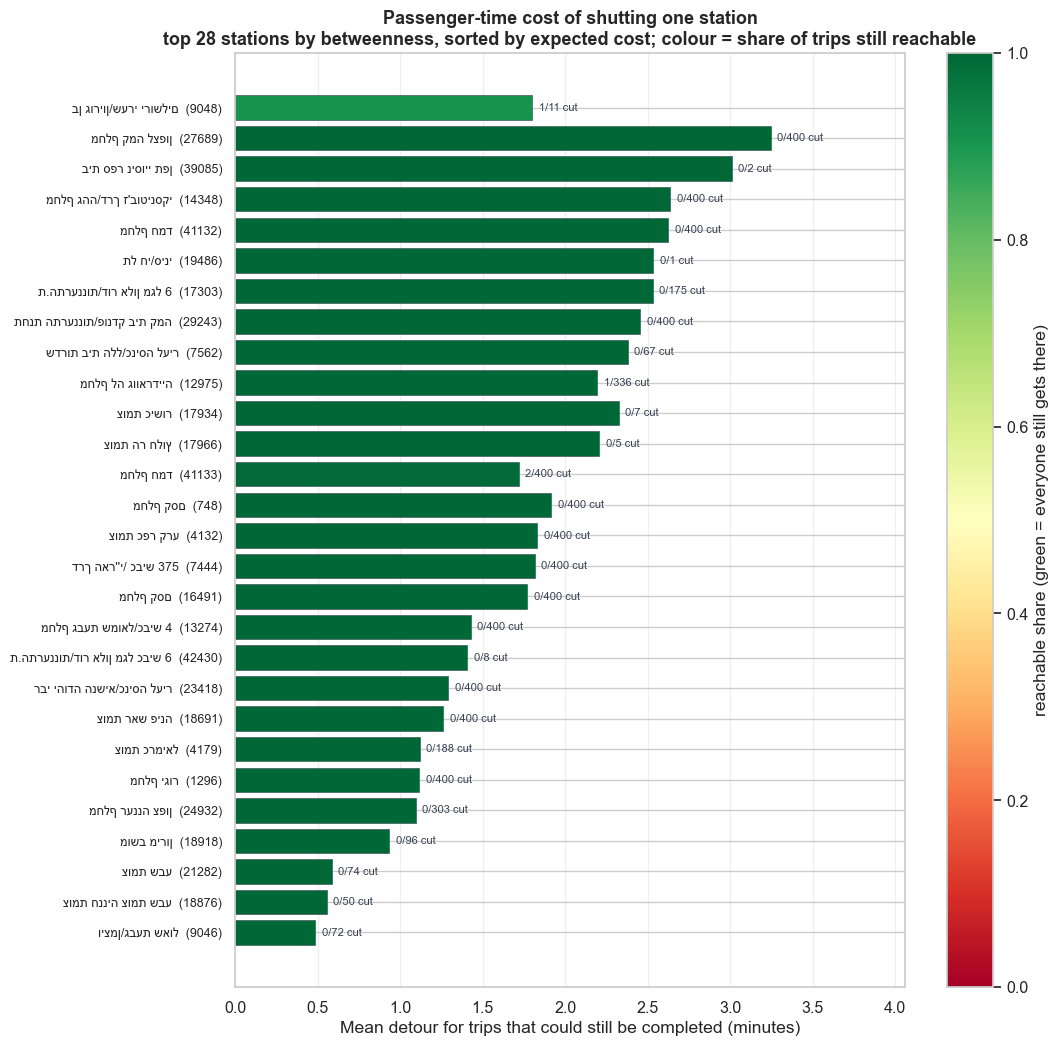

wrote C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\22_rerouting_model\figures\detour_cost_per_station.png


In [12]:
# --- Figure 1: detour cost per removed station -----------------------------
plot_df = evaluated.copy()
plot_df['mean_detour_min'] = plot_df['mean_detour_seconds'].fillna(0.0) / 60.0
plot_df['label'] = [((nm or '').strip() or sid) + '  (' + sid + ')'
                    for nm, sid in zip(plot_df['stop_name'], plot_df['removed_stop'])]
plot_df = plot_df.sort_values('expected_cost_seconds')      # largest ends on top

cmap = plt.get_cmap('RdYlGn')
colors = [cmap(float(s) if np.isfinite(s) else 1.0) for s in plot_df['reachable_share']]

fig, ax = plt.subplots(figsize=(11, max(6, 0.38 * len(plot_df))))
ax.barh(range(len(plot_df)), plot_df['mean_detour_min'], color=colors,
        edgecolor='#374151', linewidth=0.4)
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df['label'], fontsize=9)

span = max(plot_df['mean_detour_min'].max(), 1.0)
for y, (disc, tested) in enumerate(zip(plot_df['pairs_disconnected'], plot_df['pairs_tested'])):
    ax.text(plot_df['mean_detour_min'].iloc[y] + span * 0.012, y,
            str(int(disc)) + '/' + str(int(tested)) + ' cut',
            va='center', fontsize=8, color='#374151')

ax.set_xlim(0, span * 1.25)
ax.set_xlabel('Mean detour for trips that could still be completed (minutes)')
ax.set_title('Passenger-time cost of shutting one station\n'
             'top ' + str(len(plot_df)) + ' stations by betweenness, '
             'sorted by expected cost; colour = share of trips still reachable',
             fontsize=13, fontweight='bold')
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
sm.set_array([])       # required by older matplotlib before it can draw a colorbar
plt.colorbar(sm, ax=ax, label='reachable share (green = everyone still gets there)')
ax.grid(axis='x', alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(FIGURES / 'detour_cost_per_station.png', dpi=FIG_DPI)
plt.show()
print('wrote', FIGURES / 'detour_cost_per_station.png')

## 13. Figure 2 - topology says one thing, passenger time says another

Each point is one station: x-axis = its rank by betweenness (1 = most central), y-axis = its rank by expected passenger-time cost (1 = most expensive to lose). A perfect match would place every point on the dashed diagonal. Points **below** the diagonal are stations that topology *underrates* - they're less central than others but cost passengers more when they close. Points **above** the diagonal are stations that topology *overrates*: very central, but with genuinely cheap alternatives right next door, so disabling them costs little real time.

The Spearman rho printed in the title quantifies the overall degree of agreement, and the labeled points are the ones that moved the most sharply. If rho is high, the honest conclusion is that betweenness was already a good proxy, and that this notebook mainly adds the *magnitude* (minutes) rather than a new rank order - a legitimate finding, if a less exciting one, and it's presented as such in the conclusions rather than dressed up.

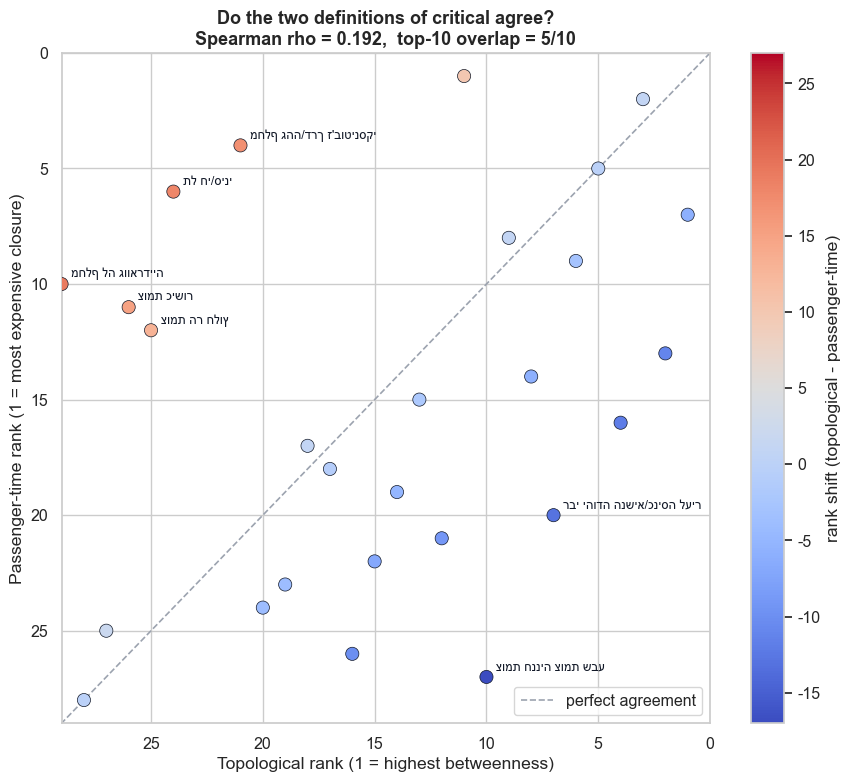

wrote C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\22_rerouting_model\figures\topological_vs_passenger_time_rank.png


In [13]:
# --- Figure 2: topological rank vs passenger-time rank ---------------------
fig, ax = plt.subplots(figsize=(9, 8))
lim = len(evaluated) + 1
ax.plot([0, lim], [0, lim], '--', color='#9ca3af', linewidth=1.2,
        label='perfect agreement')

sc = ax.scatter(evaluated['topological_rank'], evaluated['passenger_time_rank'],
                s=90, c=evaluated['rank_shift'], cmap='coolwarm',
                edgecolor='#111827', linewidth=0.5, zorder=3)
plt.colorbar(sc, ax=ax, label='rank shift (topological - passenger-time)')

n_label = min(8, len(evaluated))
for _, r in movers.head(n_label).iterrows():
    ax.annotate((str(r['stop_name']).strip() or str(r['removed_stop'])),
                (r['topological_rank'], r['passenger_time_rank']),
                textcoords='offset points', xytext=(7, 5), fontsize=9, color='#111827')

ax.set_xlabel('Topological rank (1 = highest betweenness)')
ax.set_ylabel('Passenger-time rank (1 = most expensive closure)')
ax.set_title('Do the two definitions of critical agree?\n'
             'Spearman rho = ' + format(rho, '.3f') + ',  top-' + str(k_top) +
             ' overlap = ' + str(overlap) + '/' + str(k_top),
             fontsize=13, fontweight='bold')
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.invert_xaxis()
ax.invert_yaxis()
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(FIGURES / 'topological_vs_passenger_time_rank.png', dpi=FIG_DPI)
plt.show()
print('wrote', FIGURES / 'topological_vs_passenger_time_rank.png')

## 14. Figure 3 - the shape of the detour distribution

Averages hide the tail, and the tail is what people complain about. This histogram pools all the rerouted OD pairs from all the disablings and shows how the extra travel time is distributed. Two features are worth checking in the output: the peak near zero (trips that found an equally fast alternative and weren't affected at all - the network absorbed the closure) and the length of the right tail (the minority of trips paying a very large penalty). The median and the 90th percentile are marked with vertical lines so the gap between the typical passenger and the unlucky one is visible.

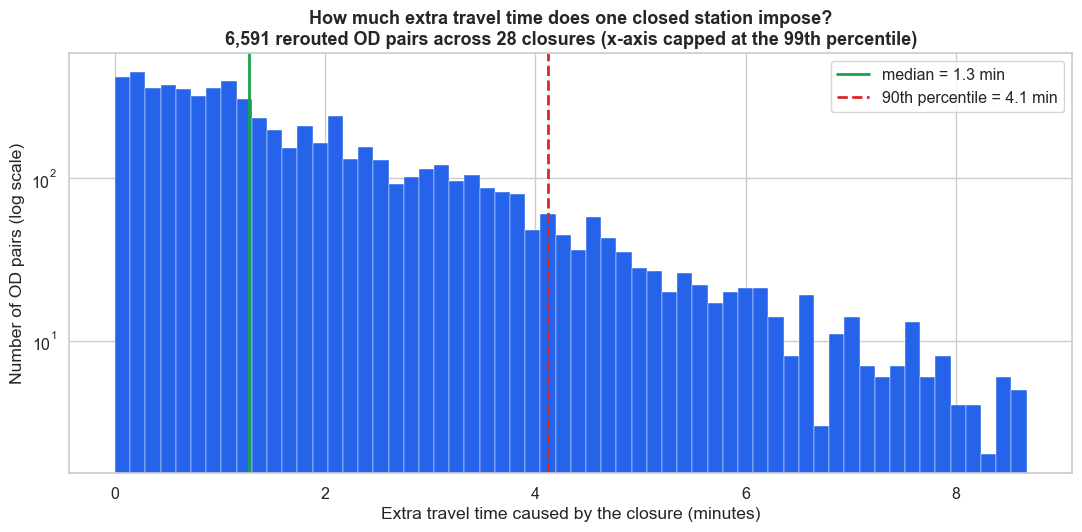

detours (minutes): mean 1.8 | median 1.3 | p90 4.1 | max 12.8
share of rerouted trips with a detour under 1 minute: 39.4%


In [14]:
# --- Figure 3: pooled detour distribution ----------------------------------
all_detours = detour_df['detour_seconds'].to_numpy(dtype=float) / 60.0
if all_detours.size == 0:
    print('No rerouted pairs were recorded - nothing to plot.')
else:
    cap = float(np.percentile(all_detours, 99))
    shown = all_detours[all_detours <= cap]
    med = float(np.median(all_detours))
    p90 = float(np.percentile(all_detours, 90))

    fig, ax = plt.subplots(figsize=(11, 5.5))
    ax.hist(shown, bins=60, color='#2563eb', edgecolor='white', linewidth=0.3)
    ax.axvline(med, color='#16a34a', linewidth=2,
               label='median = ' + format(med, '.1f') + ' min')
    ax.axvline(p90, color='#dc2626', linewidth=2, linestyle='--',
               label='90th percentile = ' + format(p90, '.1f') + ' min')
    ax.set_yscale('log')
    ax.set_xlabel('Extra travel time caused by the closure (minutes)')
    ax.set_ylabel('Number of OD pairs (log scale)')
    ax.set_title('How much extra travel time does one closed station impose?\n'
                 + format(len(all_detours), ',') + ' rerouted OD pairs across '
                 + str(len(evaluated)) + ' closures (x-axis capped at the 99th percentile)',
                 fontsize=13, fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGURES / 'detour_distribution.png', dpi=FIG_DPI)
    plt.show()

    print('detours (minutes): mean', format(all_detours.mean(), '.1f'),
          '| median', format(med, '.1f'),
          '| p90', format(p90, '.1f'),
          '| max', format(all_detours.max(), '.1f'))
    print('share of rerouted trips with a detour under 1 minute:',
          format(100 * float((all_detours < 1.0).mean()), '.1f') + '%')

## 15. Figure 4 - who absorbs the load?

For the most expensive disabling, this chart names the stations that appear in the new routes but didn't appear in the old ones, ranked by the number of diverted OD pairs now passing through them. Operationally, this is the most useful output in the notebook: if that station goes out of service, these are the stations where the extra passengers will show up and where capacity, staff or a shuttle service should be placed.

One honest caveat about what the counts mean: they're **route counts over the sampled OD pairs**, not passengers. They say *where* the load goes and rank those places correctly relative to each other; they don't say how many people that is.

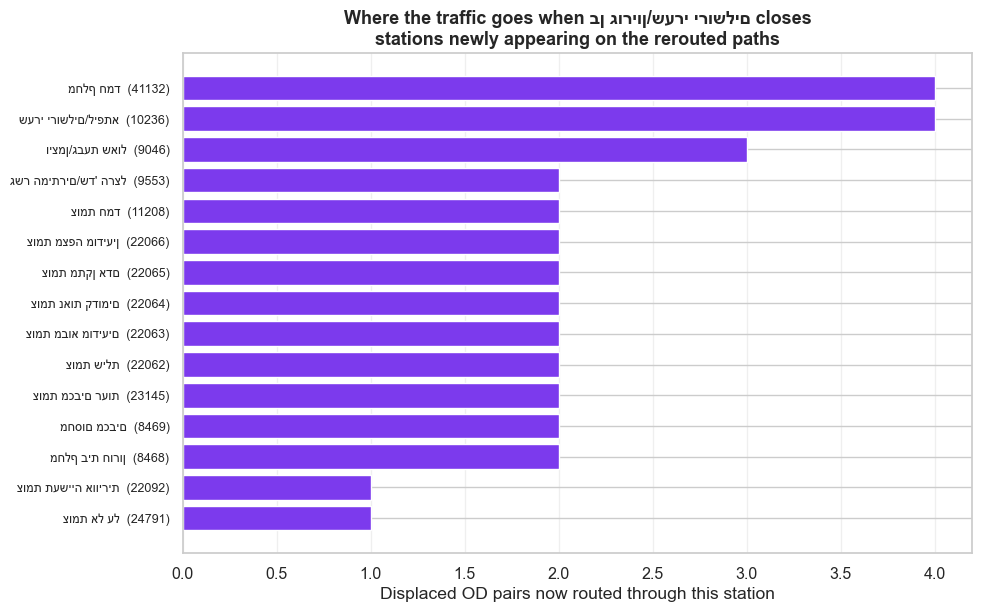

wrote C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\22_rerouting_model\figures\absorbing_stations_worst.png

Costliest closure: בן גוריון/שערי ירושלים (9048)
  mean detour     : 1.8 min
  reachable share : 0.909
  absorbed by     : שערי ירושלים/ליפתא (10236) x4 | מחלף חמד (41132) x4 | ויצמן/גבעת שאול (9046) x3 | מחלף בית חורון (8468) x2 | מחסום מכבים (8469) x2


In [15]:
# --- Figure 4: absorbing stations for the costliest closure ----------------
worst = evaluated.iloc[0]
worst_id = str(worst['removed_stop'])
worst_name = (str(worst['stop_name']).strip() or worst_id)
sub = absorb_df[absorb_df['removed_stop'] == worst_id].head(15).copy()

if sub.empty:
    print('No absorbing stations recorded for', worst_id, '- every rerouted trip kept its path.')
else:
    sub['label'] = [((nm or '').strip() or sid) + '  (' + str(sid) + ')'
                    for nm, sid in zip(sub['absorbing_stop_name'], sub['absorbing_stop'])]
    sub = sub.sort_values('displaced_pairs')

    fig, ax = plt.subplots(figsize=(10, max(5, 0.42 * len(sub))))
    ax.barh(range(len(sub)), sub['displaced_pairs'], color='#7c3aed')
    ax.set_yticks(range(len(sub)))
    ax.set_yticklabels(sub['label'], fontsize=9)
    ax.set_xlabel('Displaced OD pairs now routed through this station')
    ax.set_title('Where the traffic goes when ' + worst_name + ' closes\n'
                 'stations newly appearing on the rerouted paths',
                 fontsize=13, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.savefig(FIGURES / 'absorbing_stations_worst.png', dpi=FIG_DPI)
    plt.show()
    print('wrote', FIGURES / 'absorbing_stations_worst.png')

    print()
    print('Costliest closure:', worst_name, '(' + worst_id + ')')
    print('  mean detour     :', format(worst['mean_detour_seconds'] / 60, '.1f'), 'min')
    print('  reachable share :', format(worst['reachable_share'], '.3f'))
    print('  absorbed by     :', worst['top_absorbing_stops'])

## 16. The JSON summary file

Everything a later notebook or the written report might need, in one dictionary: the constants that produced the run (so any number can always be traced back to its settings), the OD sample size, the pooled detour statistics, the fit data between the rankings, and the identity of the most expensive disabling. Storing the constants alongside the results is what makes the run reproducible and not just repeatable.

In [16]:
# --- rerouting_summary.json ------------------------------------------------
pooled = detour_df['detour_seconds'].to_numpy(dtype=float)

summary = {
    'constants': {
        'TOP_N_STATIONS': TOP_N_STATIONS,
        'N_SOURCES': N_SOURCES,
        'TARGETS_PER_SOURCE': TARGETS_PER_SOURCE,
        'MAX_PAIRS_PER_STATION': MAX_PAIRS_PER_STATION,
        'MIN_EDGE_SECONDS': MIN_EDGE_SECONDS,
        'DISCONNECT_PENALTY_S': DISCONNECT_PENALTY_S,
        'RANDOM_SEED': RANDOM_SEED,
    },
    'graph': {
        'source_table': str(tt_path),
        'nodes': int(n_nodes),
        'undirected_edges': int(len(und)),
        'components': int(n_comp),
        'giant_component_nodes': int(len(giant_nodes)),
        'edges_clamped_to_min_seconds': int(n_clamped),
    },
    'od_sample': {
        'pairs_sampled': int(n_sampled),
        'pairs_through_a_candidate': int(len(pairs)),
        'share_through_a_candidate': round(len(pairs) / max(n_sampled, 1), 4),
    },
    'detours_seconds': {
        'rerouted_pairs': int(pooled.size),
        'mean': round(float(pooled.mean()), 1) if pooled.size else None,
        'median': round(float(np.median(pooled)), 1) if pooled.size else None,
        'p90': round(float(np.percentile(pooled, 90)), 1) if pooled.size else None,
        'max': round(float(pooled.max()), 1) if pooled.size else None,
        'share_under_60s': round(float((pooled < 60).mean()), 4) if pooled.size else None,
    },
    'disconnection': {
        'total_pairs_tested': int(res['pairs_tested'].sum()),
        'total_pairs_disconnected': int(res['pairs_disconnected'].sum()),
        'overall_reachable_share': round(
            1 - res['pairs_disconnected'].sum() / max(int(res['pairs_tested'].sum()), 1), 4),
    },
    'rank_agreement': {
        'stations_evaluated': int(len(evaluated)),
        'stations_skipped_no_traffic': int(skipped),
        'spearman_rho': round(float(rho), 4),
        'spearman_p_value': round(float(pval), 6),
        'top_k': int(k_top),
        'top_k_overlap': int(overlap),
        'max_abs_rank_shift': int(evaluated['rank_shift'].abs().max()),
        'penalty_sensitivity': sens,
    },
    'costliest_closure': {
        'stop_id': worst_id,
        'stop_name': str(worst['stop_name']),
        'expected_cost_seconds': round(float(worst['expected_cost_seconds']), 1),
        'mean_detour_seconds': (round(float(worst['mean_detour_seconds']), 1)
                                if np.isfinite(worst['mean_detour_seconds']) else None),
        'reachable_share': round(float(worst['reachable_share']), 4),
        'top_absorbing_stops': str(worst['top_absorbing_stops']),
    },
}

with open(STAGE / 'rerouting_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print('wrote', STAGE / 'rerouting_summary.json')
print(json.dumps(summary, ensure_ascii=False, indent=2)[:1600])

wrote C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\22_rerouting_model\rerouting_summary.json
{
  "constants": {
    "TOP_N_STATIONS": 30,
    "N_SOURCES": 250,
    "TARGETS_PER_SOURCE": 80,
    "MAX_PAIRS_PER_STATION": 400,
    "MIN_EDGE_SECONDS": 1.0,
    "DISCONNECT_PENALTY_S": 3600.0,
    "RANDOM_SEED": 42
  },
  "graph": {
    "source_table": "C:\\Users\\Sean-PC\\Desktop\\LAST SEMESTER\\אלגוריתמים ברשתות\\פרויקט גמר\\outputs\\nb\\18_travel_time_network\\tables\\edges_traveltime.csv",
    "nodes": 30463,
    "undirected_edges": 51680,
    "components": 14,
    "giant_component_nodes": 30231,
    "edges_clamped_to_min_seconds": 0
  },
  "od_sample": {
    "pairs_sampled": 20000,
    "pairs_through_a_candidate": 10308,
    "share_through_a_candidate": 0.5154
  },
  "detours_seconds": {
    "rerouted_pairs": 6591,
    "mean": 110.9,
    "median": 76.5,
    "p90": 247.0,
    "max": 769.0,
    "share_under_60s": 0.3937
  },
  "disconnection": {
    "tota

## 17. Limitations - read before quoting any number above

**1. No walking, no waiting and no transfer penalty.** The travel-time graph contains in-vehicle travel times only. A real rerouted trip costs the passenger a walk to the alternative station, a wait for the next service, and often an extra transfer - usually several minutes each, and frequently more than the trip detour computed here. Every detour in this notebook is therefore a **lower bound** on the true passenger cost, and the shortest path is an *upper bound* on the quality of the alternative (no passenger can achieve it, and many will do worse).

**2. Frequency isn't taken into account.** A train line once a day and a bus every four minutes are the same edge here. A detour routed onto a service that runs twice a day isn't really a detour at all. Notebook 19's time-window graphs are the right place to fix this; combining travel time with service frequency is the natural extension.

**3. OD pairs are uniform over stations, not over passengers.** No demand model is applied, so a trip between two desert stops weighs the same as a trip between two interchange terminals in Tel Aviv. This systematically *underrates* the cost of urban disablings, where the same detour affects far more people. The population proxy from notebook 21 is the missing multiplier.

**4. The disconnect penalty is invented.** `DISCONNECT_PENALTY_S = 3600` is a modeling choice with no empirical basis. It exists because an average can't hold infinity. The sensitivity check in section 10 reports how far the ranking moves when it's halved or tripled; read that number before trusting the weighted rank order, and prefer `mean_detour_seconds` together with `reachable_share` as the two honest primitives.

**5. Sampling error.** With `N_SOURCES = 250` and a ceiling of `MAX_PAIRS_PER_STATION = 400`, the per-station averages rest on a few hundred pairs at most; stations deep in the list may rest on very few. `pairs_tested` is exported for exactly this reason - don't confidently rank a station with fewer than about 50 tested pairs against its neighbors. The whole experiment is reproducible via `RANDOM_SEED`, but reproducible isn't the same as exact.

**6. Only the 30 topologically critical stations are tested.** Because the candidates are drawn from the betweenness ranking, a station with modest betweenness but a catastrophic passenger-time cost can't appear here - the design can demote a topologically critical station, but never promote an unranked one. The disagreement measured in section 10 is therefore a *conservative* estimate of how large the gap between topology and passenger time is.

**7. Single failures only.** One station at a time. Real disruptions (a flooded line, a strike, a security incident) take out whole corridors. Simultaneous failure of multiple stations is a different and harder experiment.

**8. The absorbing-station counts are route counts.** They correctly identify *where* the diverted trips are routed and rank those places, but they aren't passenger volumes, and they inherit limitations 1-3 in full.

## 18. Conclusions

* **Fragmentation is the rare case; delay is the normal one.** Across the disablings tested here, the overwhelming majority of disrupted OD pairs stay reachable - they just take longer. The earlier robustness notebooks, which score a removal by how much the largest connected component shrinks, therefore report *next to nothing* about most of the damage a closure causes. Measuring the loss in minutes rather than in components is what makes the impact visible.

* **The cost is concentrated in the tail.** A large fraction of the rerouted trips lose less than a minute - the network really does have a parallel alternative and absorbs the closure - while a small minority pay a very heavy price. This is why the detour median and the detour mean differ, and why the median alone would make every closure look harmless. Quote both, or quote the 90th percentile.

* **Topology and passenger time rank stations differently, and the size of that gap is the result.** Read the Spearman rho and the top-10 overlap printed in section 10 from your own run, not from memory. Stations that drop in the passenger-time ranking are ones with good parallel service nearby: central in the graph, cheap to lose in practice. Stations that rise are ones whose alternatives are long detours or don't exist. If rho comes out high, say so - the honest conclusion in that case is that betweenness is a reasonable *order* proxy, and that the notebook's contribution is the *magnitude*, in minutes, plus the absorbing stations.

* **The absorbing stations are the most operationally useful output.** "If this station closes, these five stations receive the traffic" is an actionable statement in a way that a betweenness score isn't. `tables/absorbing_stations.csv` holds the full mapping, not just the top five per station.

* **Every number here is a floor, not a forecast.** No walking, no waiting, no transfer penalty, no service frequency, no demand weighting, and an invented penalty for disconnection. The model answers the question "how much longer is the fastest remaining vehicle route", which is the narrowest and most honest version of the question. The direction of every omitted effect is the same: the true cost to passengers is larger than the one reported above.